In [1]:
import matplotlib.pyplot as plt
import seaborn as sns 
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("C:\\Users\\admin\\OneDrive\\Desktop\\Utpal\\Amazon Project\\Data\\Full_Data.csv")

In [4]:
df = df.drop_duplicates()

In [5]:
df = df.dropna()

In [6]:
df=df[df['Quantity Ordered']!="Quantity Ordered"]

In [7]:
df['Order Date']=pd.to_datetime(df['Order Date'])
df['Price Each']=pd.to_numeric(df['Price Each'])
df['Order ID']=df['Order ID'].astype("Int32")
df['Quantity Ordered']=df['Quantity Ordered'].astype("Int32")

C:\Users\admin\AppData\Local\Temp\ipykernel_6732\3912047783.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Order Date']=pd.to_datetime(df['Order Date'])


In [8]:
df["sales"] = df['Quantity Ordered']*df['Price Each']
df['month'] = df['Order Date'].dt.month
df['month_name']=df['Order Date'].dt.month_name()
df['year']=df['Order Date'].dt.year
df['day']=df['Order Date'].dt.day
df['hour']=df['Order Date'].dt.hour
df['day_name']=df['Order Date'].dt.day_name()
df['quarter'] = df['Order Date'].dt.quarter

In [9]:
def time_slot(hour):
    if hour < 6:
        return 'Late Night'
    elif hour < 12:
        return 'Morning'
    elif hour < 17:
        return 'Afternoon'
    elif hour < 21:
        return 'Evening'
    else:
        return 'Night'

df['time_slot'] = df['hour'].apply(time_slot)

In [10]:
def o(i):
     return i.split(',')[2].split(' ')[1].strip()
    
df['Full city']=df['Purchase Address'].apply(o)

In [11]:
state_map = {
    'TX': 'Texas',
    'MA': 'Massachusetts',
    'CA': 'California',
    'WA': 'Washington',
    'GA': 'Georgia',
    'NY': 'New York',
    'OR': 'Oregon',
    'ME': 'Maine'
}

df['Full city'] = df['Full city'].replace(state_map)

In [12]:
def get_zip_code(address):
    return address.split(',')[-1]

df['zip_code'] = df['Purchase Address'].apply(get_zip_code)

In [13]:
df['zip_code'] = df['zip_code'].str.split().str[1]

In [14]:
def c(j):
     return j.split(',')[1].strip()
    
df['city']=df['Purchase Address'].apply(c)

In [15]:
def cat(product):
    if 'Phone' in product:
        return 'Phone'
    elif 'Laptop' in product:
        return 'Laptop'
    elif 'Headphones' in product:
        return 'Headphones'
    elif 'Monitor' in product:
        return 'Monitor'
    elif 'Cable' in product:
        return 'Charging Cable'
    elif 'Batteries' in product:
        return 'Battery'
    elif 'TV' in product:
        return 'TV'
    elif 'Dryer' in product:
        return 'Home Appliance'
    elif 'Washing Machine' in product:
        return 'Home Appliance'
    else:
        return 'Other'

df['Category'] = df['Product'].apply(cat)

In [16]:
def sort(u):
    return str(u).strip()

for col in df.columns:
    df[col] = df[col].apply(sort)


In [17]:
df['Order Date']=pd.to_datetime(df['Order Date'])
df['Price Each']=pd.to_numeric(df['Price Each'])
df['Order ID']=df['Order ID'].astype("Int32")
df['Quantity Ordered']=df['Quantity Ordered'].astype("Int32")

In [18]:
def quantity_type(o):
    if o >= 2:
        return 'Bulk'
    else:
        return 'Single'

df['quantity_category'] = df['Quantity Ordered'].apply(quantity_type)

In [19]:
def price_type(price):
    if price <= 15:
        return 'Budget'
    elif price <= 150:
        return 'Affordable'
    elif price <= 500:
        return 'Mid Range'
    else:
        return 'Premium'

df['price_category'] = df['Price Each'].apply(price_type)

In [20]:
df['sales']=df['sales'].astype("Float32")
df['month'] = df['month'].astype(int)
df['year'] = df['year'].astype(int)
df['day'] = df['day'].astype(int)
df['hour'] = df['hour'].astype(int)
df['quarter'] = df['quarter'].astype(int)

In [21]:
df.columns

Index(['Order ID', 'Product', 'Quantity Ordered', 'Price Each', 'Order Date',
       'Purchase Address', 'sales', 'month', 'month_name', 'year', 'day',
       'hour', 'day_name', 'quarter', 'time_slot', 'Full city', 'zip_code',
       'city', 'Category', 'quantity_category', 'price_category'],
      dtype='object')

1. Total Sales by Product

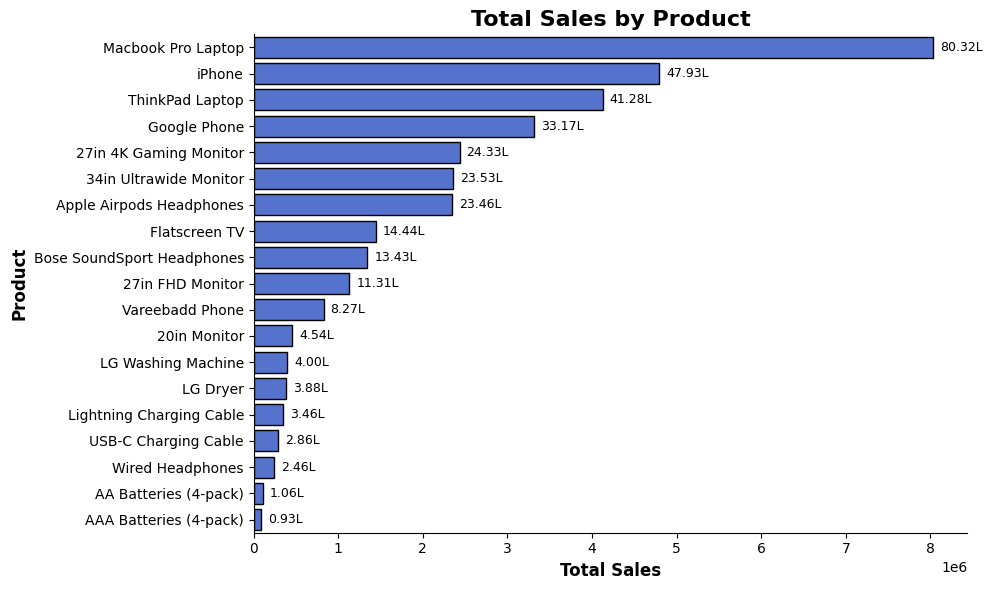

In [22]:
sales_by_product = df.groupby('Product', as_index=False)['sales'].sum().sort_values(by='sales', ascending=False)
plt.figure(figsize=(10,6))
ax = sns.barplot(data=sales_by_product, y='Product', x='sales', color='royalblue', edgecolor='black')
ax.set_title('Total Sales by Product', fontsize=16, fontweight='bold')
ax.set_xlabel('Total Sales', fontsize=12, fontweight='bold')
ax.set_ylabel('Product', fontsize=12, fontweight='bold')
for i in ax.containers:
    ax.bar_label(i,labels=[f"{v/100000:.2f}L" for v in sales_by_product["sales"]],fontsize=9,padding=5)
sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()

2. Total Quantity Sold by Product

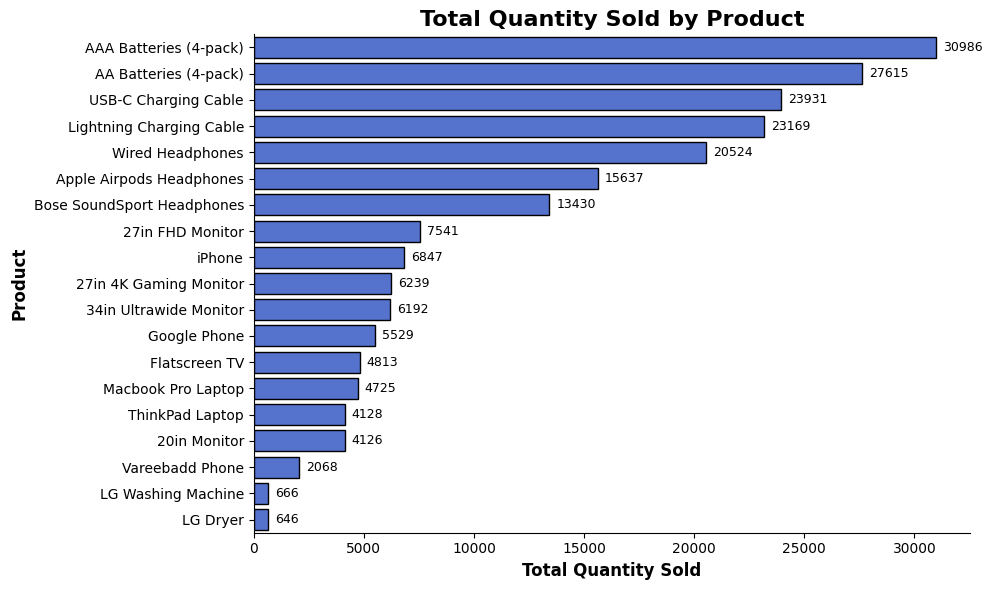

In [23]:
quantity_by_product = df.groupby('Product', as_index=False)['Quantity Ordered'].sum().sort_values(by='Quantity Ordered', ascending=False)
plt.figure(figsize=(10,6))
ax = sns.barplot(data=quantity_by_product, y='Product', x='Quantity Ordered', color='royalblue', edgecolor='black')
ax.set_title('Total Quantity Sold by Product', fontsize=16, fontweight='bold')
ax.set_xlabel('Total Quantity Sold', fontsize=12, fontweight='bold')
ax.set_ylabel('Product', fontsize=12, fontweight='bold')
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', fontsize=9, padding=5)
sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()

3.Average Price by Product

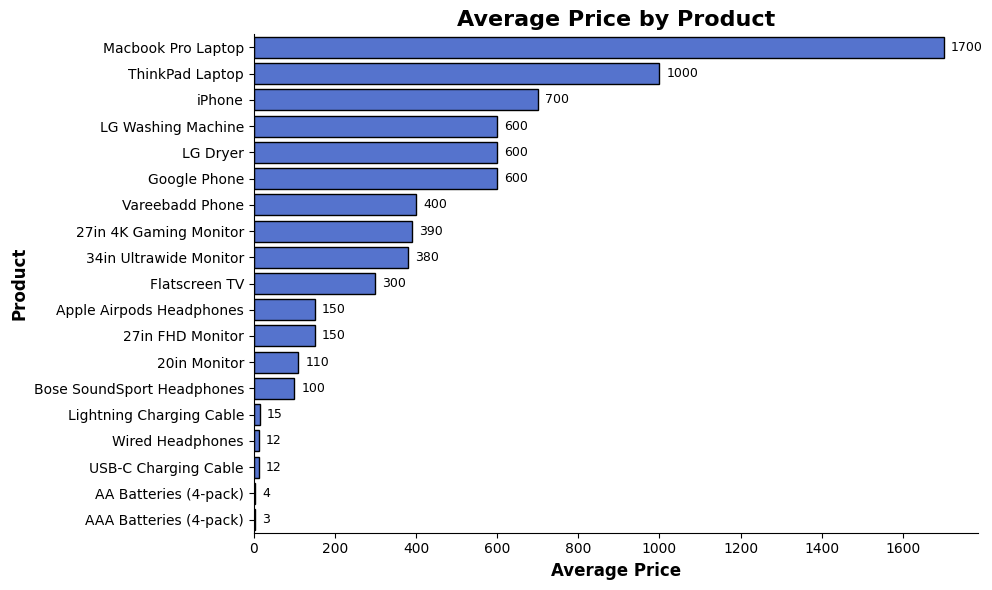

In [24]:
quantity_by_product = df.groupby('Product', as_index=False)['Price Each'].mean().sort_values(by='Price Each', ascending=False)
plt.figure(figsize=(10,6))
ax = sns.barplot(data=quantity_by_product, y='Product', x='Price Each', color='royalblue', edgecolor='black')
ax.set_title('Average Price by Product', fontsize=16, fontweight='bold')
ax.set_xlabel('Average Price', fontsize=12, fontweight='bold')
ax.set_ylabel('Product', fontsize=12, fontweight='bold')
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', fontsize=9, padding=5)
sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()

4.Monthly Sales Trend

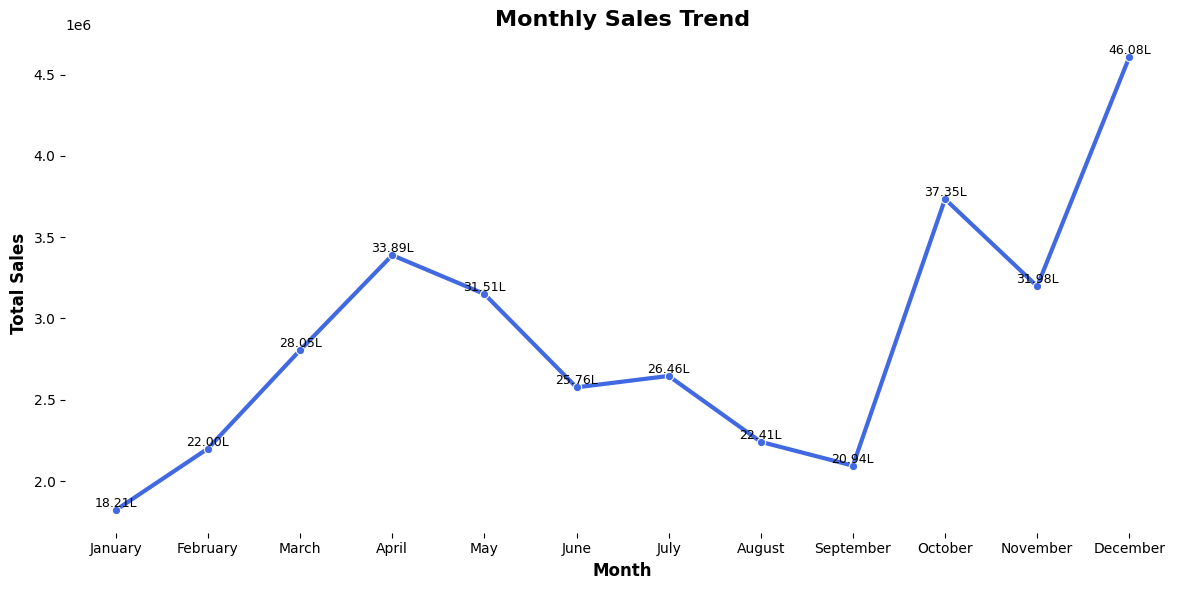

In [25]:
month_order = ["January","February","March","April","May","June","July","August","September","October","November","December"]
monthly_sales = df.groupby('month_name', as_index=False)['sales'].sum()
monthly_sales['month_name'] = pd.Categorical(monthly_sales['month_name'], categories=month_order, ordered=True)
monthly_sales = monthly_sales.sort_values('month_name')
plt.figure(figsize=(12,6))
ax = sns.lineplot(data=monthly_sales,x='month_name',y='sales',marker='o',linewidth=3,color='royalblue')
ax.set_title('Monthly Sales Trend', fontsize=16, fontweight='bold')
ax.set_xlabel('Month', fontsize=12, fontweight='bold')
ax.set_ylabel('Total Sales', fontsize=12, fontweight='bold')
for x, y in zip(monthly_sales['month_name'], monthly_sales['sales']):
    ax.text(x, y, f"{y/100000:.2f}L", ha='center', va='bottom', fontsize=9)
sns.despine(top=True, right=True ,left=True, bottom=True)
plt.tight_layout()
plt.show()

5.Monthly Orders

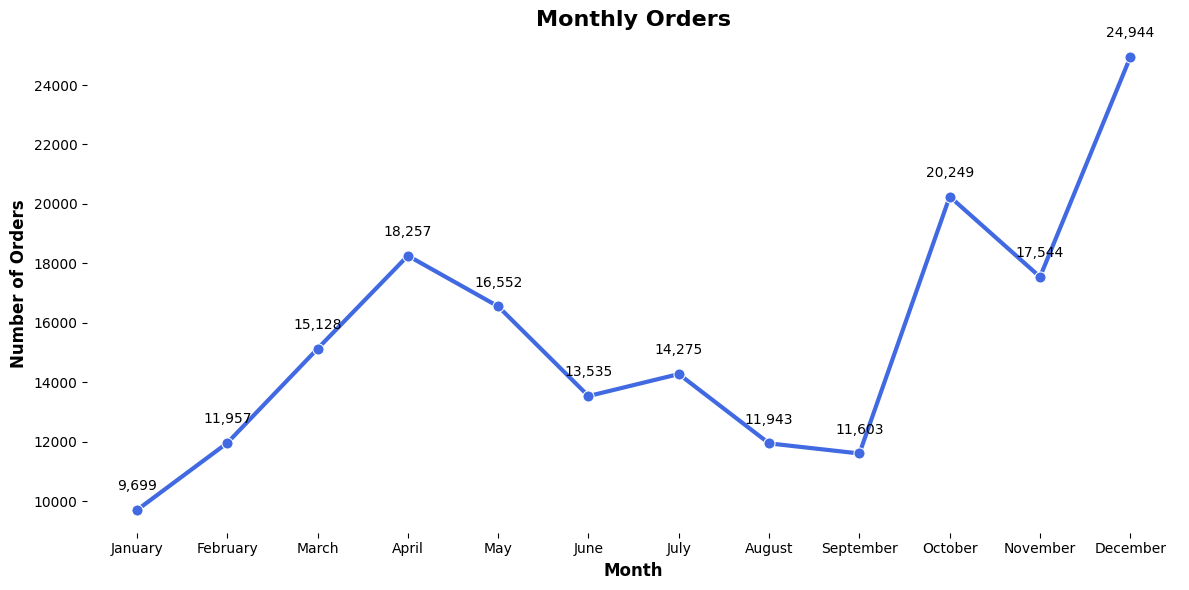

In [26]:
monthly_orders = df.groupby('month_name', as_index=False)['Order ID'].count()
month_order = ["January","February","March","April","May","June","July","August","September","October","November","December"]
monthly_orders['month_name'] = pd.Categorical(monthly_orders['month_name'],categories=month_order,ordered=True)
monthly_orders = monthly_orders.sort_values('month_name')
plt.figure(figsize=(12,6))
ax = sns.lineplot(data=monthly_orders,x='month_name',y='Order ID',marker='o',linewidth=3,markersize=8,color='royalblue')
ax.set_title('Monthly Orders', fontsize=16, fontweight='bold')
ax.set_xlabel('Month', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Orders', fontsize=12, fontweight='bold')
for x, y in zip(monthly_orders['month_name'], monthly_orders['Order ID']):
    ax.annotate(f"{y:,}",xy=(x, y),xytext=(0, 12),textcoords="offset points",ha="center",va="bottom",fontsize=10)
sns.despine(top=True, right=True,left=True, bottom=True)
plt.tight_layout()
plt.show()

6.Sales by Quarter

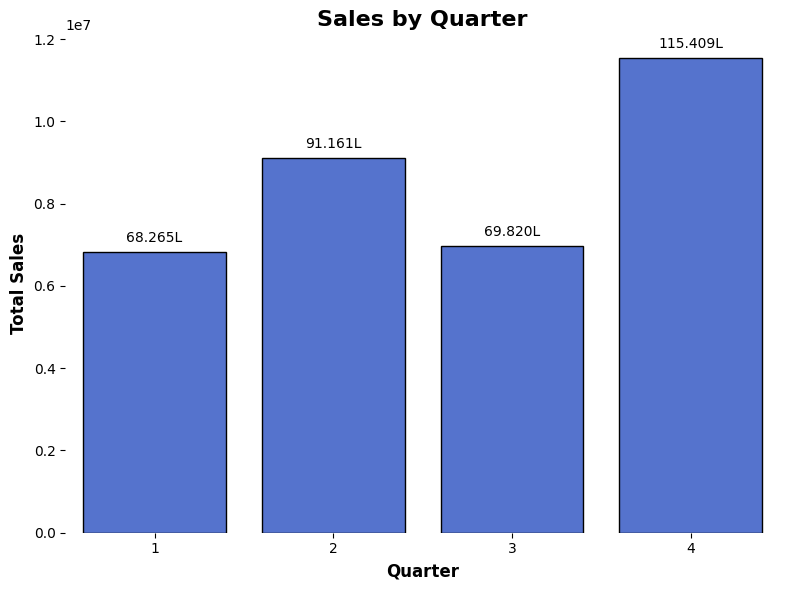

In [27]:
quarterly_sales = df.groupby('quarter', as_index=False)['sales'].sum()
quarterly_sales = quarterly_sales.sort_values('quarter')
plt.figure(figsize=(8,6))
ax = sns.barplot(data=quarterly_sales,x='quarter',y='sales',color='royalblue',edgecolor='black')
ax.set_title('Sales by Quarter', fontsize=16, fontweight='bold')
ax.set_xlabel('Quarter', fontsize=12, fontweight='bold')
ax.set_ylabel('Total Sales', fontsize=12, fontweight='bold')
for container in ax.containers:
    ax.bar_label(container,labels=[f"{v/100000:.3f}L" for v in quarterly_sales['sales']],fontsize=10,padding=5)
sns.despine(top=True, right=True, left=True, bottom=True)
plt.tight_layout()
plt.show()

7.Sales by Hour

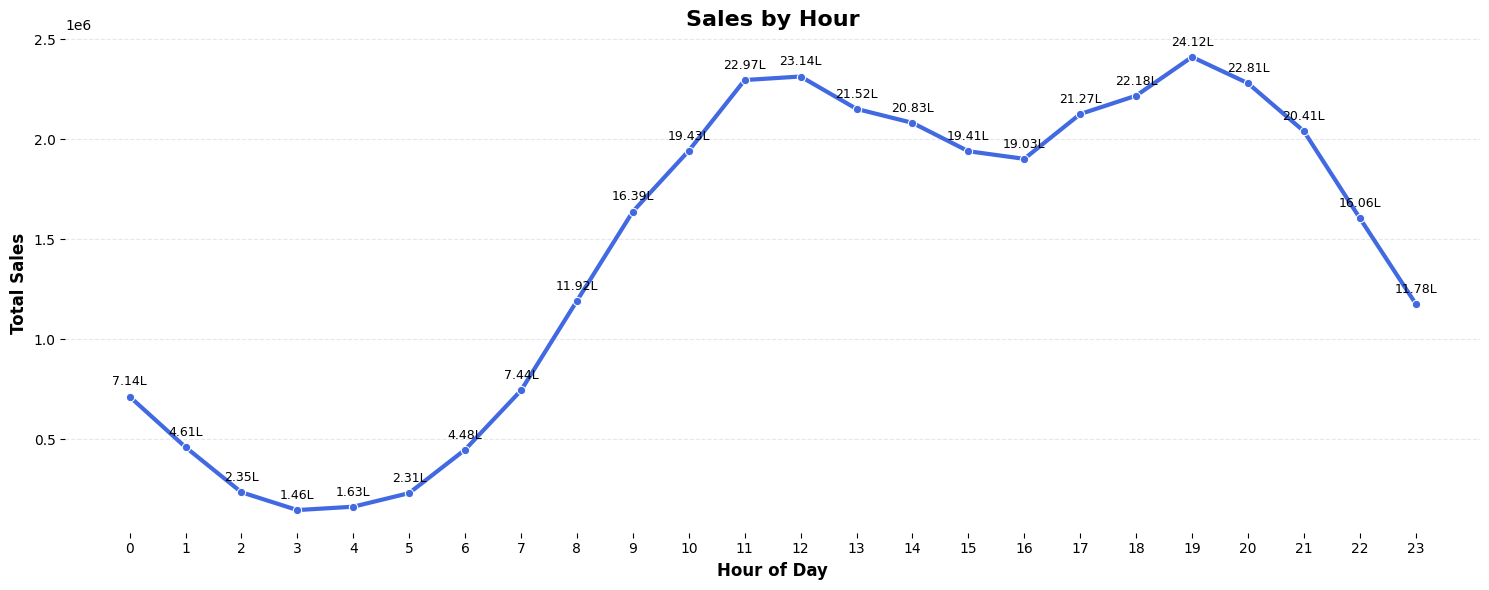

In [28]:
hourly_sales = df.groupby('hour', as_index=False)['sales'].sum().sort_values('hour')
plt.figure(figsize=(15,6))
ax = sns.lineplot(data=hourly_sales,x='hour',y='sales',marker='o',linewidth=3,color='royalblue')
ax.set_title('Sales by Hour', fontsize=16, fontweight='bold')
ax.set_xlabel('Hour of Day', fontsize=12, fontweight='bold')
ax.set_ylabel('Total Sales', fontsize=12, fontweight='bold')
for x, y in zip(hourly_sales['hour'], hourly_sales['sales']):
    ax.annotate(f"{y/100000:.2f}L",(x, y),textcoords="offset points",xytext=(0, 8),ha="center",fontsize=9)
ax.set_xticks(range(24))
ax.grid(axis='y', linestyle='--', alpha=0.3)
sns.despine(top=True, right=True, left=True, bottom=True)
plt.tight_layout()
plt.show()

8.Orders by Hour

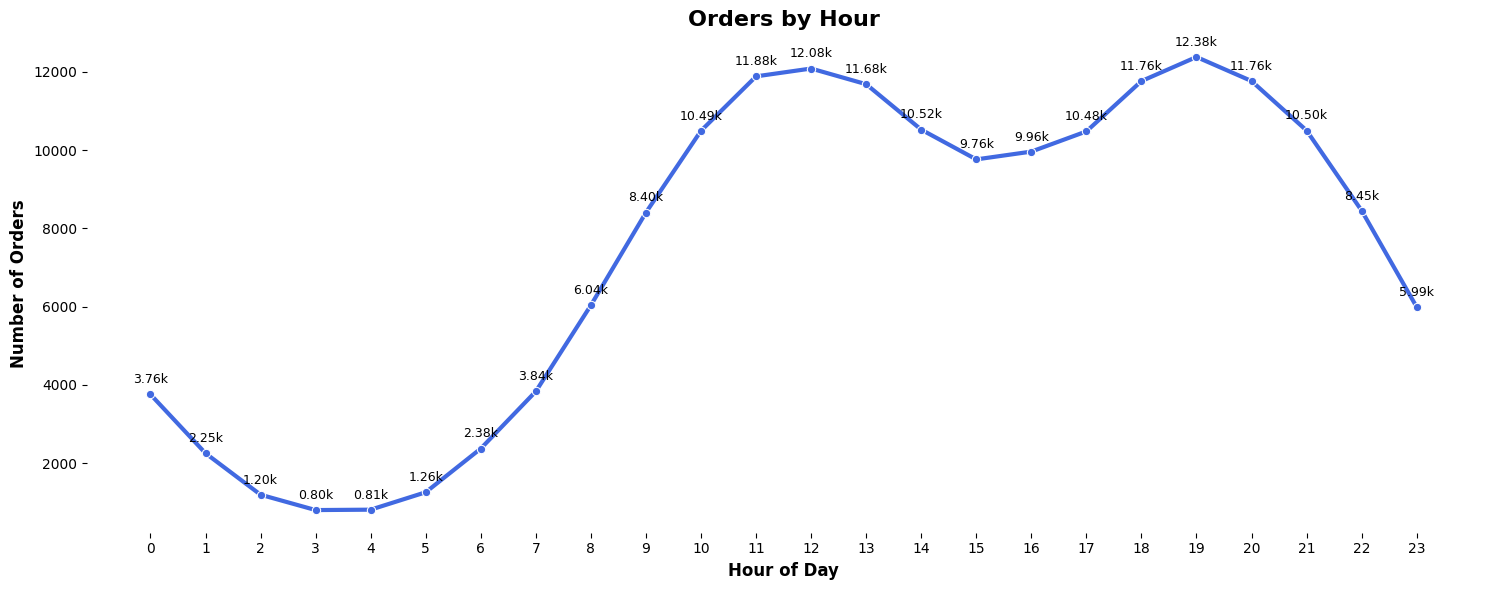

In [29]:
hourly_orders = df.groupby('hour', as_index=False)['Order ID'].nunique().sort_values('hour')
plt.figure(figsize=(15,6))
ax = sns.lineplot(data=hourly_orders, x='hour', y='Order ID', marker='o', linewidth=3, color='royalblue')
ax.set_title('Orders by Hour', fontsize=16, fontweight='bold')
ax.set_xlabel('Hour of Day', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Orders', fontsize=12, fontweight='bold')
for x, y in zip(hourly_orders['hour'], hourly_orders['Order ID']):
    ax.annotate(f"{y/1000:.2f}k", (x, y), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9)
ax.set_xticks(range(24))
sns.despine(top=True, right=True, left=True, bottom=True)
plt.tight_layout()
plt.show()

9.Sales by Day of Week

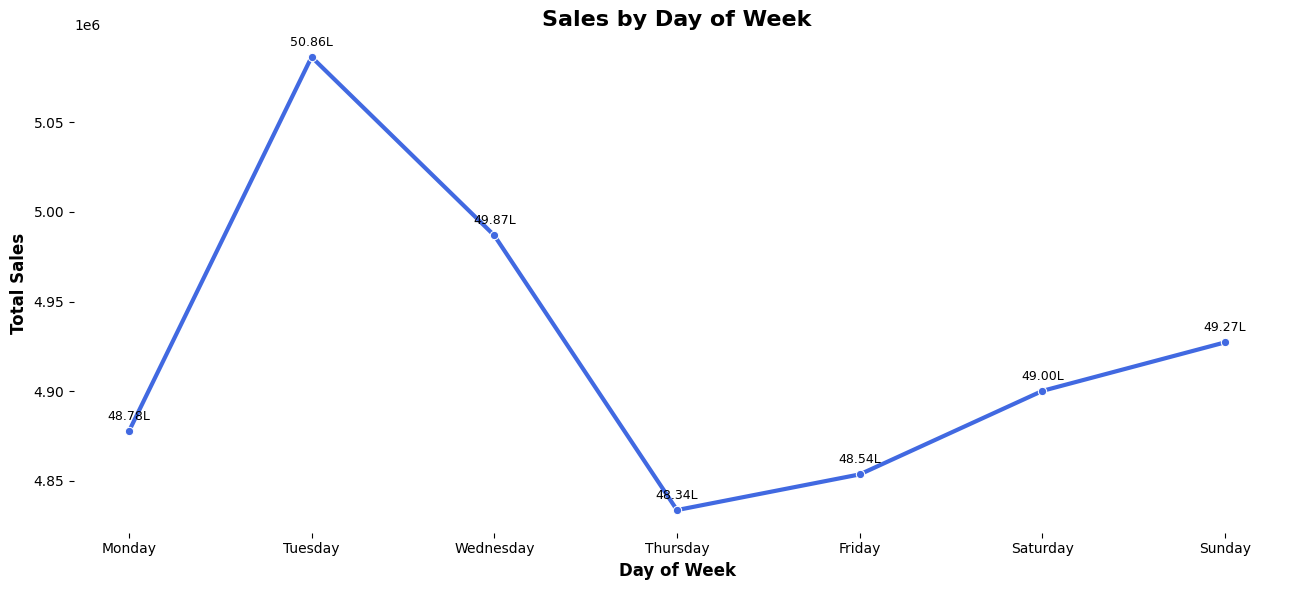

In [30]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_sales = df.groupby('day_name', as_index=False)['sales'].sum()
daily_sales['day_name'] = pd.Categorical(daily_sales['day_name'], categories=day_order, ordered=True)
daily_sales = daily_sales.sort_values('day_name')
plt.figure(figsize=(13,6))
ax = sns.lineplot(data=daily_sales, x='day_name', y='sales', marker='o', linewidth=3, color='royalblue')
ax.set_title('Sales by Day of Week', fontsize=16, fontweight='bold')
ax.set_xlabel('Day of Week', fontsize=12, fontweight='bold')
ax.set_ylabel('Total Sales', fontsize=12, fontweight='bold')
for x, y in zip(daily_sales['day_name'], daily_sales['sales']):
    ax.annotate(f"{y/100000:.2f}L", (x, y), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9)
sns.despine(top=True, right=True, left=True, bottom=True)
plt.tight_layout()
plt.show()

10.Orders by Day of Week

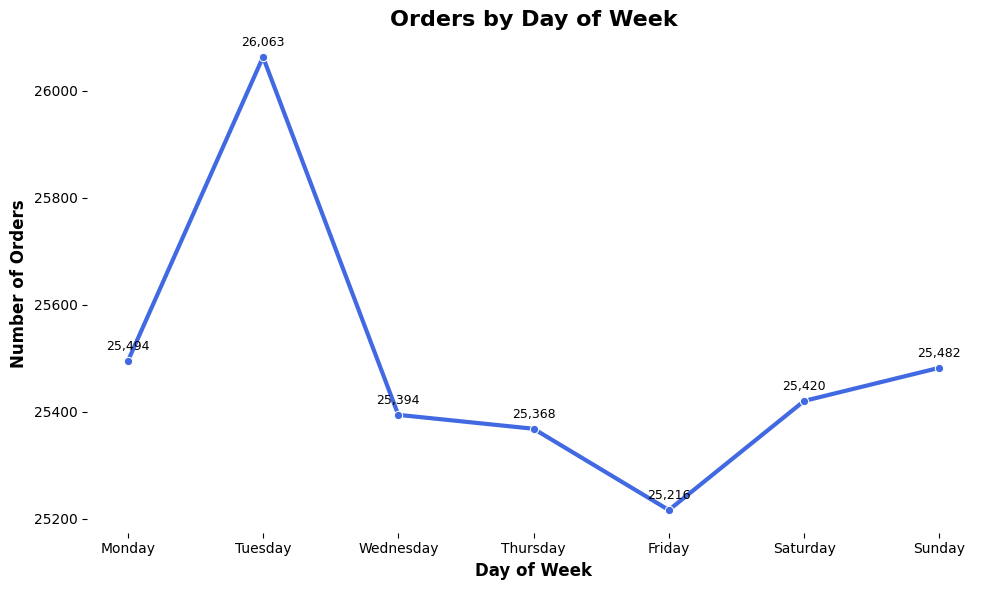

In [31]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_orders = df.groupby('day_name', as_index=False)['Order ID'].nunique()
daily_orders['day_name'] = pd.Categorical(daily_orders['day_name'], categories=day_order, ordered=True)
daily_orders = daily_orders.sort_values('day_name')
plt.figure(figsize=(10,6))
ax = sns.lineplot(data=daily_orders, x='day_name', y='Order ID', marker='o', linewidth=3, color='royalblue')
ax.set_title('Orders by Day of Week', fontsize=16, fontweight='bold')
ax.set_xlabel('Day of Week', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Orders', fontsize=12, fontweight='bold')
for x, y in zip(daily_orders['day_name'], daily_orders['Order ID']):
    ax.annotate(f"{y:,}", (x, y), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9)
sns.despine(top=True, right=True, left=True, bottom=True)
plt.tight_layout()
plt.show()

11.Sales by Time Slot

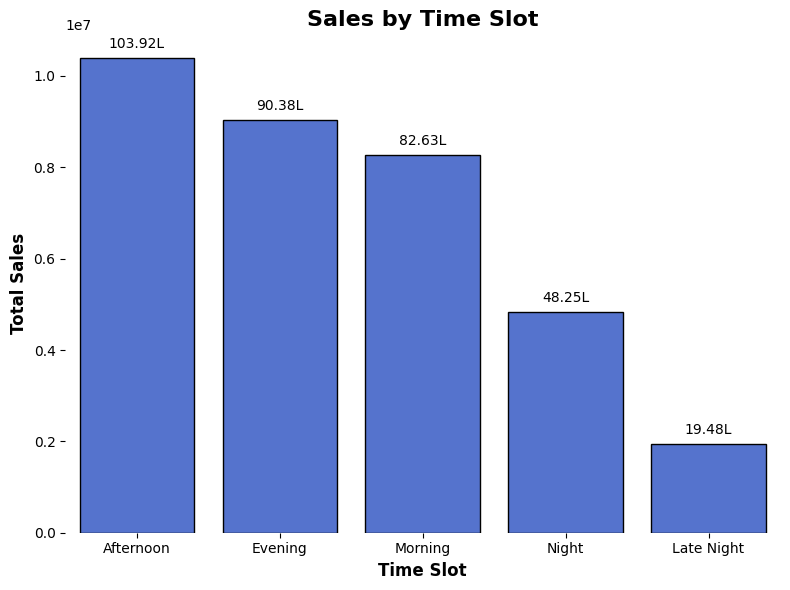

In [32]:
time_sales = df.groupby('time_slot', as_index=False)['sales'].sum().sort_values('sales', ascending=False)
plt.figure(figsize=(8,6))
ax = sns.barplot(data=time_sales, x='time_slot', y='sales', color='royalblue', edgecolor='black')
ax.set_title('Sales by Time Slot', fontsize=16, fontweight='bold')
ax.set_xlabel('Time Slot', fontsize=12, fontweight='bold')
ax.set_ylabel('Total Sales', fontsize=12, fontweight='bold')
for i in ax.containers:
    ax.bar_label(i, labels=[f"{v/100000:.2f}L" for v in time_sales['sales']], fontsize=10, padding=5)
sns.despine(top=True, right=True, left=True, bottom=True)
plt.tight_layout()
plt.show()

12. Sales by City

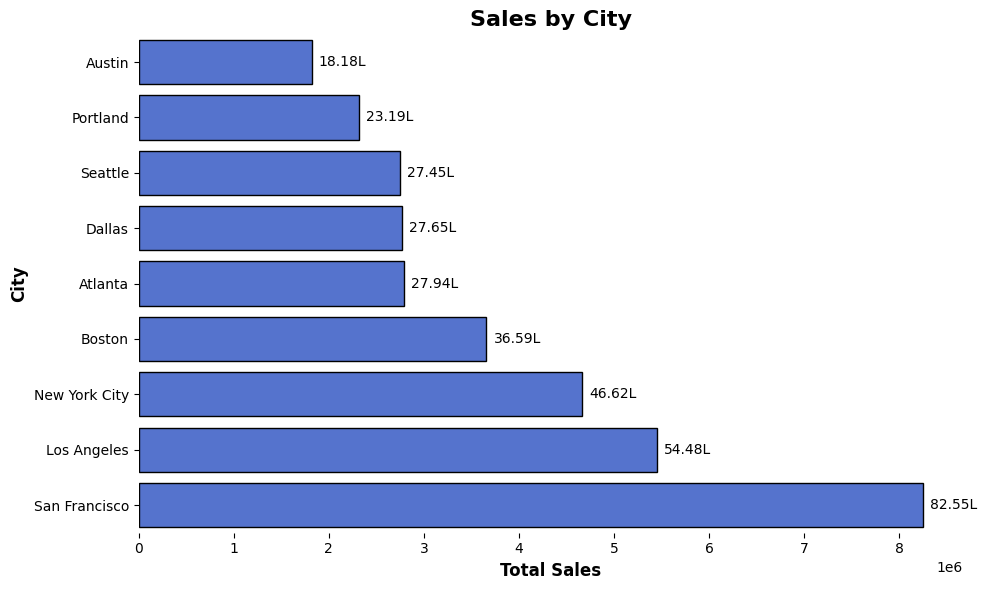

In [33]:
city_sales = df.groupby('city', as_index=False)['sales'].sum().sort_values('sales', ascending=True)
plt.figure(figsize=(10,6))
ax = sns.barplot(data=city_sales, x='sales', y='city', color='royalblue', edgecolor='black')
ax.set_title('Sales by City', fontsize=16, fontweight='bold')
ax.set_xlabel('Total Sales', fontsize=12, fontweight='bold')
ax.set_ylabel('City', fontsize=12, fontweight='bold')
for i in ax.containers:
    ax.bar_label(i, labels=[f"{v/100000:.2f}L" for v in city_sales['sales']], fontsize=10, padding=5)
sns.despine(top=True, right=True, left=True, bottom=True)
plt.tight_layout()
plt.show()

13.Orders by City

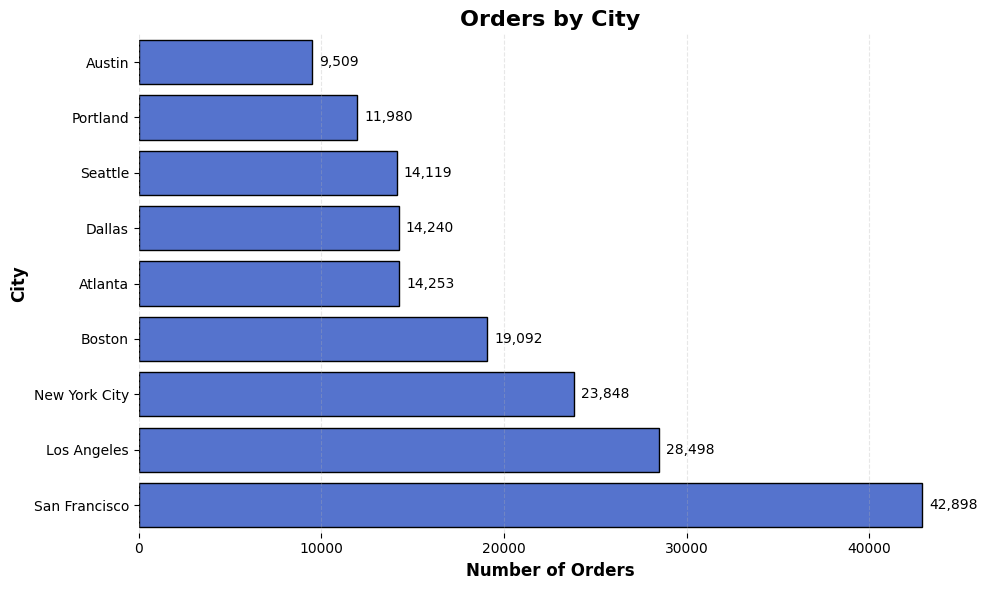

In [34]:
city_orders = df.groupby('city', as_index=False)['Order ID'].nunique().sort_values('Order ID', ascending=True)
plt.figure(figsize=(10,6))
ax = sns.barplot(data=city_orders, x='Order ID', y='city', color='royalblue', edgecolor='black')
ax.set_title('Orders by City', fontsize=16, fontweight='bold')
ax.set_xlabel('Number of Orders', fontsize=12, fontweight='bold')
ax.set_ylabel('City', fontsize=12, fontweight='bold')
for i in ax.containers:
    ax.bar_label(i, labels=[f"{v:,}" for v in city_orders['Order ID']], fontsize=10, padding=5)
ax.grid(axis='x', linestyle='--', alpha=0.3)
sns.despine(top=True, right=True, left=True, bottom=True)
plt.tight_layout()
plt.show()

14.Sales by Category

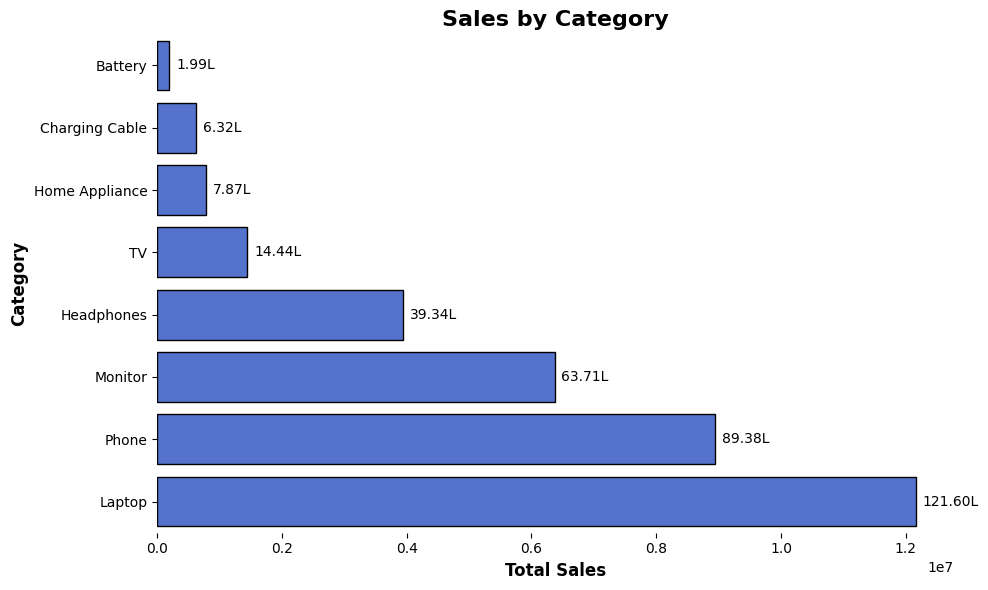

In [35]:
category_sales = df.groupby('Category', as_index=False)['sales'].sum().sort_values('sales', ascending=True)
plt.figure(figsize=(10,6))
ax = sns.barplot(data=category_sales, x='sales', y='Category', color='royalblue', edgecolor='black')
ax.set_title('Sales by Category', fontsize=16, fontweight='bold')
ax.set_xlabel('Total Sales', fontsize=12, fontweight='bold')
ax.set_ylabel('Category', fontsize=12, fontweight='bold')
for i in ax.containers:
    ax.bar_label(i, labels=[f"{v/100000:.2f}L" for v in category_sales['sales']], fontsize=10, padding=5)
sns.despine(top=True, right=True, left=True, bottom=True)
plt.tight_layout()
plt.show()

15.Quantity Sold by Category

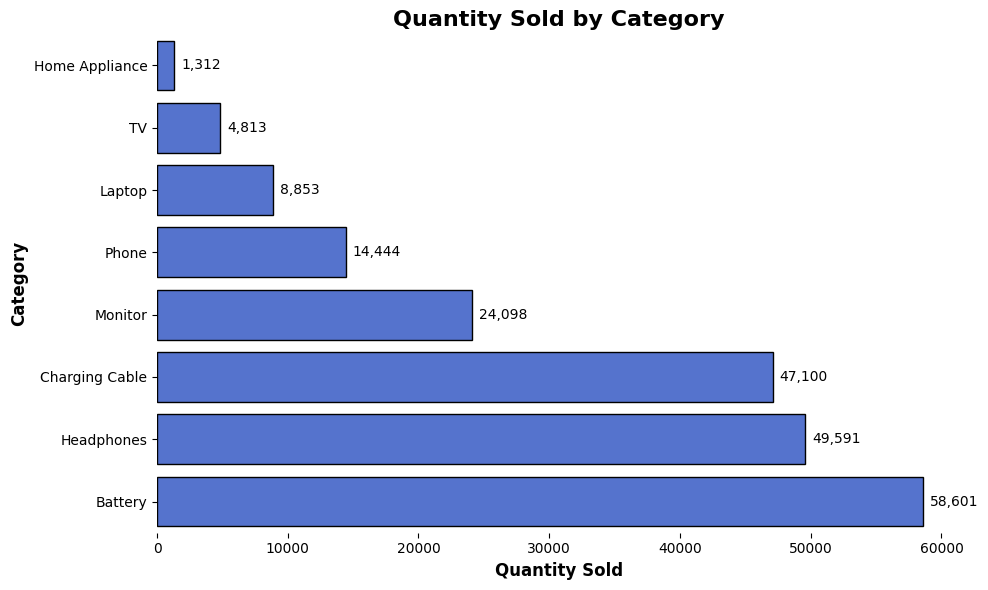

In [36]:
category_quantity = df.groupby('Category', as_index=False)['Quantity Ordered'].sum().sort_values('Quantity Ordered', ascending=True)
plt.figure(figsize=(10,6))
ax = sns.barplot(data=category_quantity, x='Quantity Ordered', y='Category', color='royalblue', edgecolor='black')
ax.set_title('Quantity Sold by Category', fontsize=16, fontweight='bold')
ax.set_xlabel('Quantity Sold', fontsize=12, fontweight='bold')
ax.set_ylabel('Category', fontsize=12, fontweight='bold')
for i in ax.containers:
    ax.bar_label(i, labels=[f"{v:,}" for v in category_quantity['Quantity Ordered']], fontsize=10, padding=5)
sns.despine(top=True, right=True, left=True, bottom=True)
plt.tight_layout()
plt.show()

16.Average Price by Category

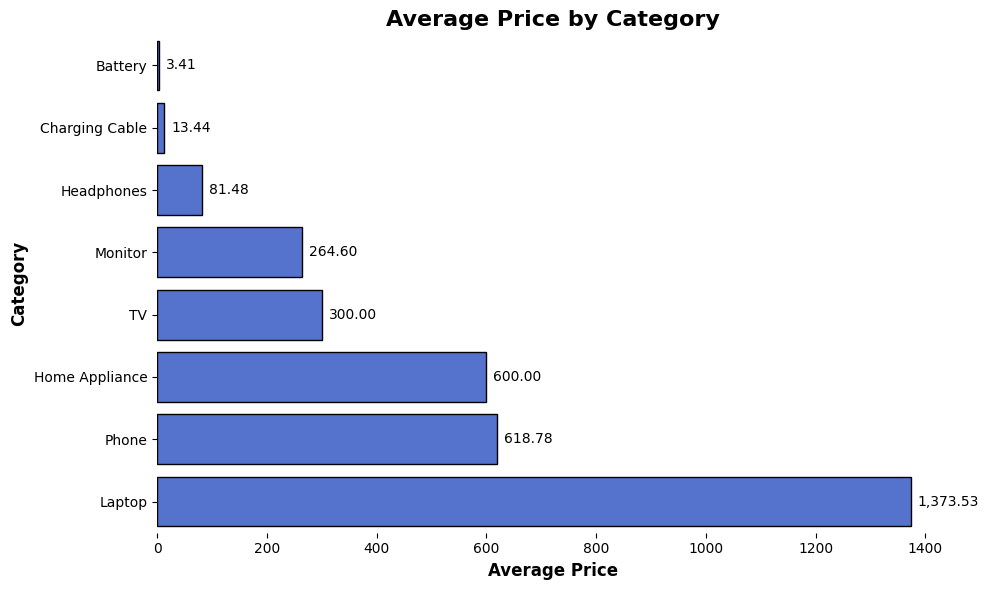

In [37]:
category_price = df.groupby('Category', as_index=False)['Price Each'].mean().sort_values('Price Each', ascending=True)
plt.figure(figsize=(10,6))
ax = sns.barplot(data=category_price, x='Price Each', y='Category', color='royalblue', edgecolor='black')
ax.set_title('Average Price by Category', fontsize=16, fontweight='bold')
ax.set_xlabel('Average Price', fontsize=12, fontweight='bold')
ax.set_ylabel('Category', fontsize=12, fontweight='bold')
for i in ax.containers:
    ax.bar_label(i, labels=[f"{v:,.2f}" for v in category_price['Price Each']], fontsize=10, padding=5)
sns.despine(top=True, right=True, left=True, bottom=True)
plt.tight_layout()
plt.show()

17. Sales by Price Category

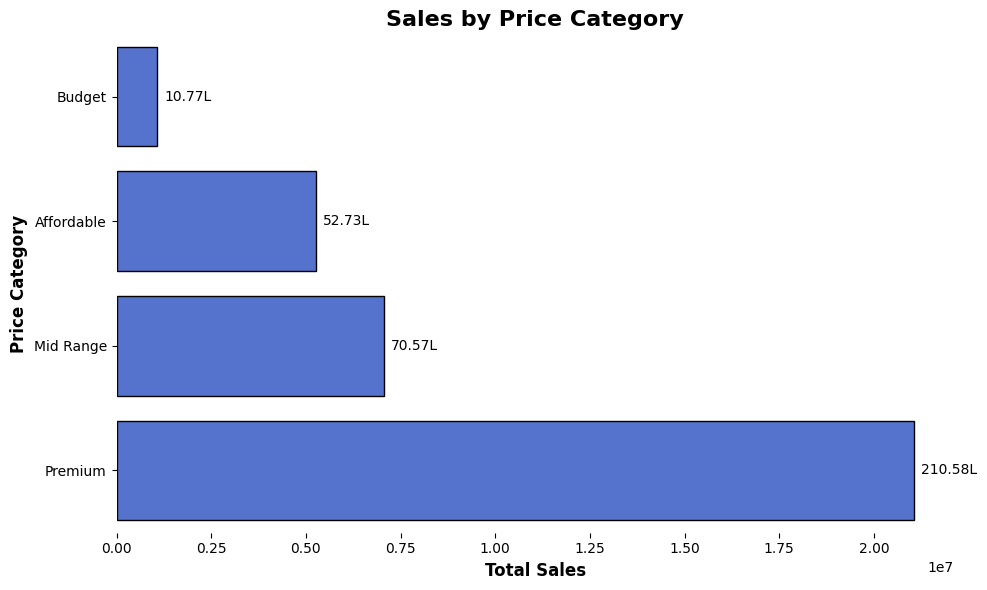

In [38]:
price_category_sales = df.groupby('price_category', as_index=False)['sales'].sum().sort_values('sales', ascending=True)
plt.figure(figsize=(10,6))
ax = sns.barplot(data=price_category_sales, x='sales', y='price_category', color='royalblue', edgecolor='black')
ax.set_title('Sales by Price Category', fontsize=16, fontweight='bold')
ax.set_xlabel('Total Sales', fontsize=12, fontweight='bold')
ax.set_ylabel('Price Category', fontsize=12, fontweight='bold')
for i in ax.containers:
    ax.bar_label(i, labels=[f"{v/100000:.2f}L" for v in price_category_sales['sales']], fontsize=10, padding=5)
sns.despine(top=True, right=True, left=True, bottom=True)
plt.tight_layout()
plt.show()

18.Sales by Quantity Category

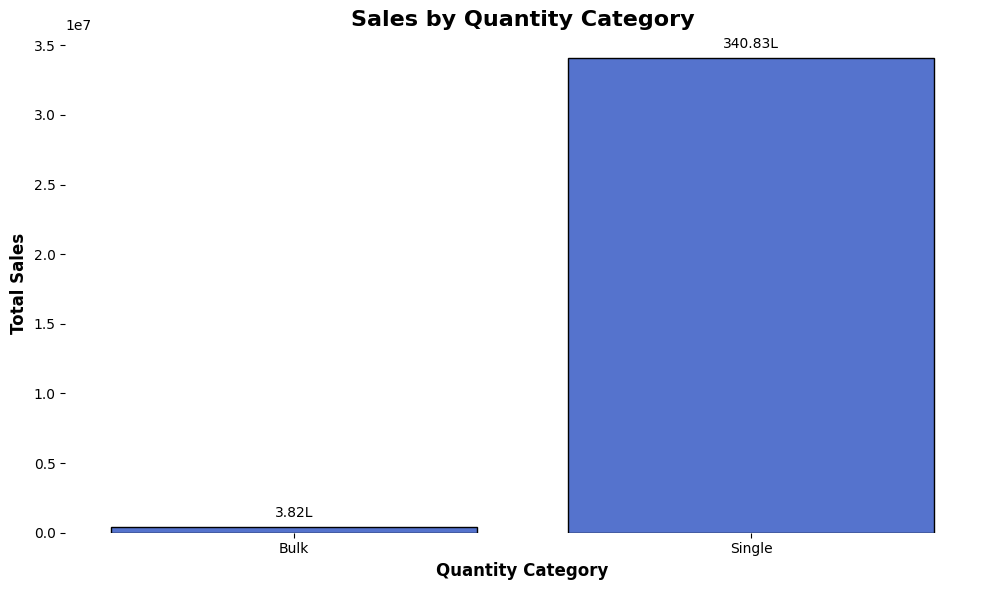

In [39]:
quantity_category_sales = df.groupby('quantity_category', as_index=False)['sales'].sum().sort_values('sales', ascending=True)
plt.figure(figsize=(10,6))
ax = sns.barplot(data=quantity_category_sales, y='sales', x='quantity_category', color='royalblue', edgecolor='black')
ax.set_title('Sales by Quantity Category', fontsize=16, fontweight='bold')
ax.set_ylabel('Total Sales', fontsize=12, fontweight='bold')
ax.set_xlabel('Quantity Category', fontsize=12, fontweight='bold')
for i in ax.containers:
    ax.bar_label(i, labels=[f"{v/100000:.2f}L" for v in quantity_category_sales['sales']], fontsize=10, padding=5)
sns.despine(top=True, right=True, left=True, bottom=True)
plt.tight_layout()
plt.show()

19. Product Count

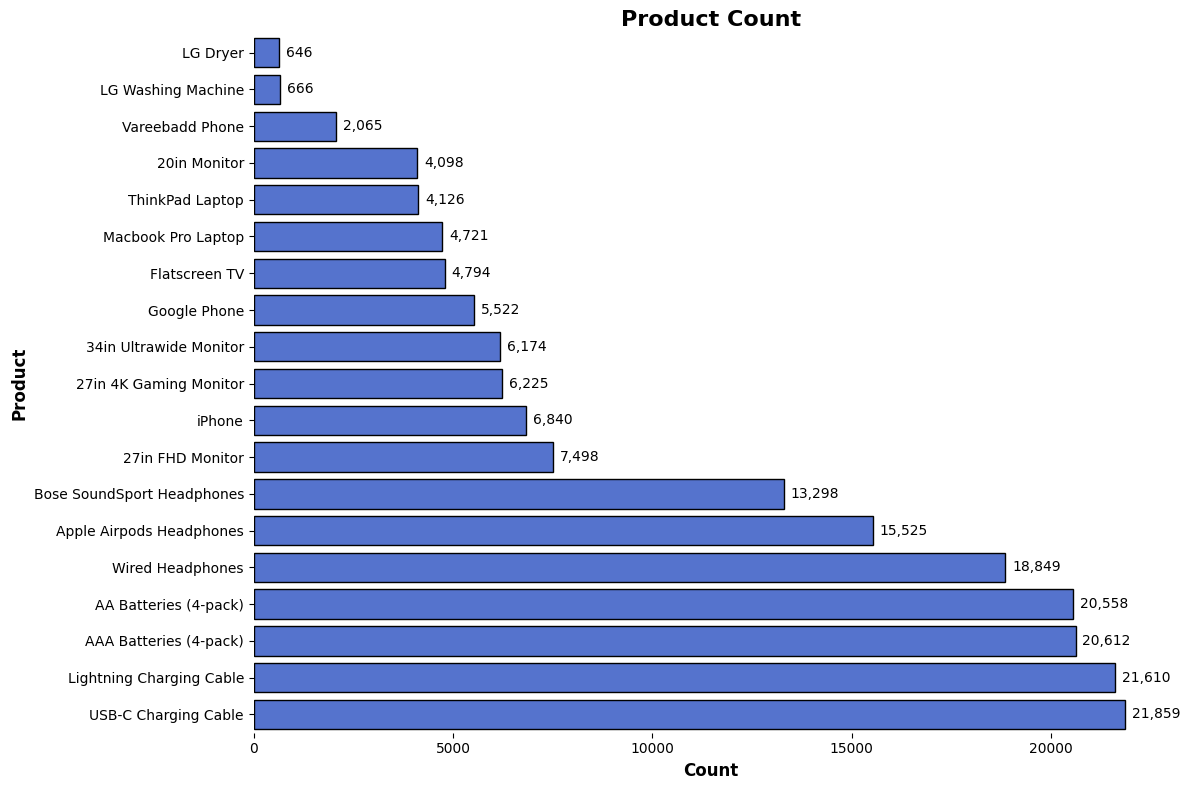

In [40]:
product_count = df['Product'].value_counts().reset_index()
product_count.columns = ['Product', 'Count']
product_count = product_count.sort_values('Count', ascending=True)
plt.figure(figsize=(12,8))
ax = sns.barplot(data=product_count, x='Count', y='Product', color='royalblue', edgecolor='black')
ax.set_title('Product Count', fontsize=16, fontweight='bold')
ax.set_xlabel('Count', fontsize=12, fontweight='bold')
ax.set_ylabel('Product', fontsize=12, fontweight='bold')
for i in ax.containers:
    ax.bar_label(i, labels=[f"{v:,}" for v in product_count['Count']], fontsize=10, padding=5)
sns.despine(top=True, right=True, left=True, bottom=True)
plt.tight_layout()
plt.show()

30.Category Count

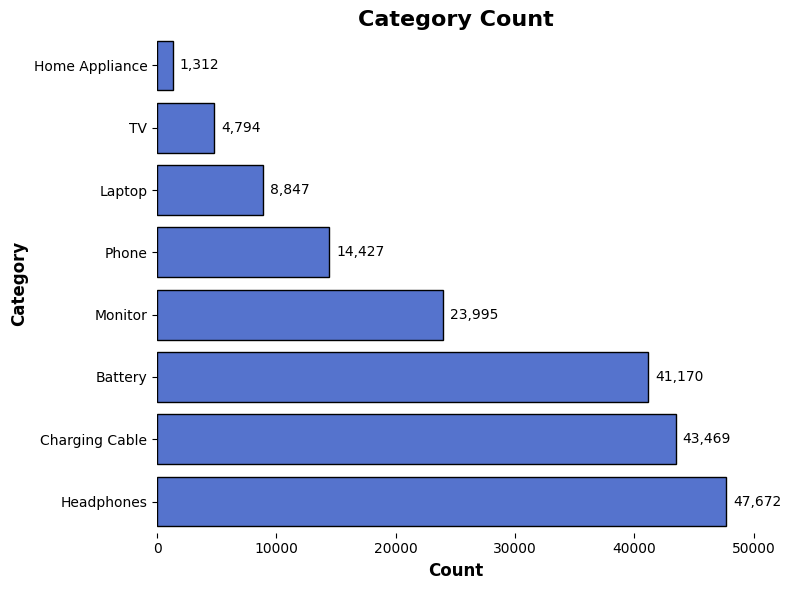

In [41]:
category_count = df['Category'].value_counts().reset_index()
category_count.columns = ['Category', 'Count']
category_count = category_count.sort_values('Count', ascending=True)
plt.figure(figsize=(8,6))
ax = sns.barplot(data=category_count, x='Count', y='Category', color='royalblue', edgecolor='black')
ax.set_title('Category Count', fontsize=16, fontweight='bold')
ax.set_xlabel('Count', fontsize=12, fontweight='bold')
ax.set_ylabel('Category', fontsize=12, fontweight='bold')
for i in ax.containers:
    ax.bar_label(i, labels=[f"{v:,}" for v in category_count['Count']], fontsize=10, padding=5)
sns.despine(top=True, right=True, left=True, bottom=True)
plt.tight_layout()
plt.show()